# Assignment 4.1

Name:  Justin
Date:  Nguyen

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

In [1]:
# Import modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, bootstrap

# Set seed for reproducibility
rng = np.random.default_rng(42)

## Problem # 4.1.

For a point estimate of the mean of a population that is assumed to have a normal distribution,
a data scientist decides to use the average of the sample lower and upper quartiles for the $n = 100$
observations, since unlike the sample mean $\bar{Y}$, the quartiles are not affected by outliers. Evaluate
the precision of this estimator compared to $\bar{Y}$ by randomly generating 100,000 samples of size
100 each from a $N(0, 1)$ distribution and comparing the standard deviation of the 100,000
estimates with the theoretical standard error of $\bar{Y}$.

`Your answer goes here`

In [2]:
# Simulate samples
simulated_samples = rng.normal(0, 1,size=10_000_000).reshape(100_000, 100)

# Take the quantiles of the samples
q1 = np.quantile(simulated_samples, 0.25, axis=1)
q3 = np.quantile(simulated_samples, 0.75, axis=1)

# Compute point estimate of the samples
midhinge = (q3 + q1) / 2

# empirical SE of midhinge
midhinge_se = midhinge.std(ddof=1)

# theoretical SE of Y_bar
Y_bar_se = 1 / np.sqrt(100)

# Calculate the precision ratio
precision_ratio = midhinge_se / Y_bar_se

# Print result
print(midhinge_se, Y_bar_se, precision_ratio)


0.11065367950788652 0.1 1.1065367950788652


Estimated standard error of .11 was calculated by:
- simulating 100,000 samples of size n = 100
- taking the 1st and 3rd quartiles of each sample 
- compute the point estimate of the samples (q3 + q1) / 2
- compute the standard error of the point estimate (standard deviation of the 100,000 midhinge estimates)

Then we find the theoretical standard error of Y_bar (1 / sqrt(100)) = .1 and compare the midhinge SE to the Y_bar SE to find the precision ratio (midhinge_se / Y_bar_se) = 1.11. The midhinge SE is 11% larger than the Y_bar SE meaning that the confidence interval is about 11% wider (less precise).

## Problem # 4.2.

For a sequence of observations of a binary random variable, you observe the geometric random
variable (Section 2.2.2) outcome of the first success on observation number $y = 3$. Find and plot
the likelihood function.

`our answer goes here`

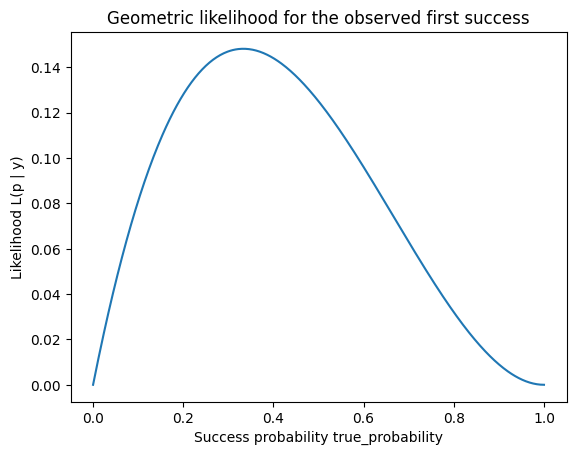

In [3]:
true_probability = np.linspace(0, 1, 501)
y = 3
likelihood = (1 - true_probability) ** (y - 1) * true_probability

plt.plot(true_probability, likelihood)
plt.xlabel('Success probability true_probability')
plt.ylabel('Likelihood L(p | y)')
plt.title('Geometric likelihood for the observed first success')
plt.show()

## Problem # 4.11.

The observations on number of hours of daily TV watching for the 10 subjects in the 2018 GSS
who identified themselves as Islamic were 0, 0, 1, 1, 1, 2, 2, 3, 3, 4.

(a)  Construct and interpret a 95% confidence interval for the population mean.
(b)  Suppose the observation of 4 was incorrectly recorded as 24. What would you obtain for
the 95% confidence interval? What does this suggest about potential effects of outliers on
confidence intervals for means?

`(a) Your answer goes here`

In [4]:
# Used np.array on the TV_GSS list to be able to use .std() method later
TV_GSS = np.array([0, 0, 1, 1, 1, 2, 2, 3, 3, 4])

n = TV_GSS.size

# Calculate mean of the observations
x_bar = TV_GSS.mean()

# Calculate standard deviation of the sample mean
std = TV_GSS.std(ddof=1)

# Calculate standard error of the sample mean
se = std / np.sqrt(n)

# Calculate the critical t-value for the 95% confidence interval
t_crit = stats.t.ppf(0.975, df=n-1) # .975 since the 5% is split between the two tails of the t-distribution

# Calculate the margin of error and confidence interval
margin = t_crit * se
CI_lower = x_bar - margin
CI_upper = x_bar + margin

# Print results
print("mean:", x_bar)
print("standard deviation:", std)
print("standard error:", se)
print("margin of error:", margin)
print("critical t-value:", t_crit)
print("lower bound of confidence interval:", CI_lower)
print("upper bound of confidence interval:", CI_upper)
print("Confidence Interval: [{}, {}]".format(CI_lower, CI_upper))

mean: 1.7
standard deviation: 1.3374935098492586
standard error: 0.42295258468165065
margin of error: 0.956785218985251
critical t-value: 2.2621571628540993
lower bound of confidence interval: 0.7432147810147489
upper bound of confidence interval: 2.656785218985251
Confidence Interval: [0.7432147810147489, 2.656785218985251]


To calculate our confidence interval = [.74, 2.66], we first calculate the standard error (.42) of the sample mean by taking the standard deviation (1.34) and dividing it by the square root of the sample size (10). Then we calculate the critical t-value (because no sigma is given) at 95% confidence level (2.26). Using this, we can now calculate our margin of error (.96) by multiplying the critical t-value with the standard error (2.26 * .42) to get .96. If we subtract the margin of error from the mean of our observations (1.7) we get the lower bound of our confidence interval (.74). If we add the margin of error to the mean of our observations, we get the upper bound of our confidence interval (2.66).

This confidence interval tells us that if we gathered many samples and built an interval the same way each time, 95% of those intervals would contain the true mean of daily TV hours for this population.

`(b) Your answer goes here`

In [5]:
# Used np.array on the TV_GSS list to be able to use .std() method later
TV_GSS = np.array([0, 0, 1, 1, 1, 2, 2, 3, 3, 24])

n = TV_GSS.size

# Calculate mean of the observations
x_bar = TV_GSS.mean()

# Calculate standard deviation of the sample mean
std = TV_GSS.std(ddof=1)

# Calculate standard error of the sample mean
se = std / np.sqrt(n)

# Calculate the critical t-value for the 95% confidence interval
t_crit = stats.t.ppf(0.975, df=n-1) # .975 since the 5% is split between the two tails of the t-distribution

# Calculate the margin of error and confidence interval
margin = t_crit * se
CI_lower = x_bar - margin
CI_upper = x_bar + margin

# Print results
print("mean:", x_bar)
print("standard deviation:", std)
print("standard error:", se)
print("margin of error:", margin)
print("critical t-value:", t_crit)
print("lower bound of confidence interval:", CI_lower)
print("upper bound of confidence interval:", CI_upper)
print("Confidence Interval: [{}, {}]".format(CI_lower, CI_upper))

mean: 3.7
standard deviation: 7.211872926716826
standard error: 2.2805944644129763
margin of error: 5.159063103237223
critical t-value: 2.2621571628540993
lower bound of confidence interval: -1.4590631032372228
upper bound of confidence interval: 8.859063103237222
Confidence Interval: [-1.4590631032372228, 8.859063103237222]


For part b of this problem, we replace the 4 in the sample with 24. The following changes are observed:
- mean: 1.7 → 3.7
- standard deviation: 1.34 → 7.21
- standard error: .42 → 2.28
- margin of error: .96 → 5.16
- critical t-value: no change
- CI lower bound: .74 → -1.46
- CI upper bound: 2.66 → 8.86

Outliers on confidence intervals moves the center of our interval and significantly widens our intervals which leads to lower precision. Another thing to note is that the lower bound of our confidence interval is now negative which means our interval now includes impossible values since nobody can watch TV for negative hours. This suggests that confidence intervals are very sensitive to outliers especially when the sample size is small like in this problem.

## Problem # 4.14.

Using the Students data file, for the corresponding population, construct a 95% confidence interval **(a)** for the mean weekly number of hours spent watching TV; **(b)** to compare females and
males on the mean weekly number of hours spent watching TV. In each case, state assumptions,
including the practical importance of each, and interpret results.

`Your answer goes here`

In [6]:
# Read data set
students = pd.read_csv('https://stat4ds.rwth-aachen.de/data/Students.dat', sep=r'\s+')

# Verify data set is read correctly
print(students.head())

weekly_tv_hours = students['tv']
x_bar = weekly_tv_hours.mean()
std = weekly_tv_hours.std(ddof=1)
n = weekly_tv_hours.size
se = std / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n-1)
margin = t_crit * se
CI_lower = x_bar - margin
CI_upper = x_bar + margin

print("mean:", x_bar)
print("standard deviation:", std)
print("sample size:", n)
print("standard error:", se)
print("margin of error:", margin)
print("critical t-value:", t_crit)
print("lower bound of confidence interval:", CI_lower)
print("upper bound of confidence interval:", CI_upper)
print("Confidence Interval: [{}, {}]".format(CI_lower, CI_upper))

   subject  gender  age  hsgpa  cogpa  dhome  dres    tv  sport  news  aids  \
0        1       0   32    2.2    3.5      0   5.0   3.0      5     0     0   
1        2       1   23    2.1    3.5   1200   0.3  15.0      7     5     6   
2        3       1   27    3.3    3.0   1300   1.5   0.0      4     3     0   
3        4       1   35    3.5    3.2   1500   8.0   5.0      5     6     3   
4        5       0   23    3.1    3.5   1600  10.0   6.0      6     3     0   

   veg  affil  ideol  relig  abor  affirm  life  
0    0      2      6      2     0       0     1  
1    1      1      2      1     1       1     3  
2    1      1      2      2     1       1     3  
3    0      3      4      1     1       1     2  
4    0      3      1      0     1       0     2  
mean: 7.266666666666667
standard deviation: 6.717335697287764
sample size: 60
standard error: 0.8672043095493365
margin of error: 1.7352718152664495
critical t-value: 2.0009953780882674
lower bound of confidence interval: 5.5

To calculate our confidence interval = [5.43, 9.00], we first calculate the standard error (.87) of the sample mean by taking the standard deviation (6.72) and dividing it by the square root of the sample size (n = 60). Then we calculate the critical t-value at 95% confidence level (2.00). We use the t distribution because the population standard deviation is unknown, with df = n - 1 = 59. Using this, we can now calculate our margin of error by multiplying the critical t-value with the standard error (2.001 x .867 = ~ 1.74). If we subtract the margin of error from the mean of our observations (7.27) we get the lower bound of our confidence interval (5.53). If we add the margin of error to the mean of our observations, we get the upper bound of our confidence interval (9.00)

This confidence interval of [5.53, 9.00] tells us that if we took many samples and created intervals the same way each time, about 95% of those intervals would contain the true mean of the weekly hours of tv watched.

`(b) answer here`

In [7]:
weekly_tv_hours_male = students[students['gender'] == 0]['tv']
x_bar = weekly_tv_hours_male.mean()
std = weekly_tv_hours_male.std(ddof=1)
n = weekly_tv_hours_male.size
se = std / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n-1)
margin = t_crit * se
CI_lower = x_bar - margin
CI_upper = x_bar + margin

print("mean for males:", x_bar)
print("standard deviation for males:", std)
print("sample size for males:", n)
print("standard error for males:", se)
print("margin of error for males:", margin)
print("critical t-value for males:", t_crit)
print("lower bound of confidence interval for males:", CI_lower)
print("upper bound of confidence interval for males:", CI_upper)
print("Confidence Interval for males: [{}, {}]".format(CI_lower, CI_upper))


mean for males: 6.5
standard deviation for males: 7.103821908964618
sample size for males: 29
standard error for males: 1.319146611734735
margin of error for males: 2.7021493405524293
critical t-value for males: 2.048407141795244
lower bound of confidence interval for males: 3.7978506594475707
upper bound of confidence interval for males: 9.20214934055243
Confidence Interval for males: [3.7978506594475707, 9.20214934055243]


To calculate our confidence interval = [3.80, 9.20], we first calculate the standard error (1.32) of the sample mean by taking the standard deviation (7.1) and dividing it by the square root of the sample size (n = 29). Then we calculate the critical t-value at 95% confidence level (2.05). We use the t distribution because the population standard deviation is unknown, with df = n - 1 = 28. Using this, we can now calculate our margin of error by multiplying the critical t-value with the standard error (2.05 x 1.32 = ~ 2.70). If we subtract the margin of error from the mean of our observations (6.5) we get the lower bound of our confidence interval (3.80). If we add the margin of error to the mean of our observations, we get the upper bound of our confidence interval (9.20)

This confidence interval of [3.80, 9.20] tells us that if we took many samples and created intervals the same way each time, about 95% of those intervals would contain the true mean of the weekly hours of tv watched.

In [8]:

weekly_tv_hours_female = students[students['gender'] == 1]['tv']
x_bar = weekly_tv_hours_female.mean()
std = weekly_tv_hours_female.std(ddof=1)
n = weekly_tv_hours_female.size
se = std / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n-1)
margin = t_crit * se
CI_lower = x_bar - margin
CI_upper = x_bar + margin

print("mean for females:", x_bar)
print("standard deviation for females:", std)
print("sample size for females:", n)
print("standard error for females:", se)
print("margin of error for females:", margin)
print("critical t-value for females:", t_crit)
print("lower bound of confidence interval for females:", CI_lower)
print("upper bound of confidence interval for females:", CI_upper)
print("Confidence Interval for females: [{}, {}]".format(CI_lower, CI_upper))

mean for females: 7.983870967741935
standard deviation for females: 6.367212722177763
sample size for females: 31
standard error for females: 1.1435851640354608
margin of error for females: 2.3355124819443542
critical t-value for females: 2.0422724563012373
lower bound of confidence interval for females: 5.648358485797581
upper bound of confidence interval for females: 10.319383449686288
Confidence Interval for females: [5.648358485797581, 10.319383449686288]


To calculate our confidence interval = [5.65, 10.32], we first calculate the standard error (1.14) of the sample mean by taking the standard deviation (6.37) and dividing it by the square root of the sample size (n = 31). Then we calculate the critical t-value at 95% confidence level (2.04). We use the t distribution because the population standard deviation is unknown, with df = n - 1 = 30. Using this, we can now calculate our margin of error by multiplying the critical t-value with the standard error (2.04 x 1.14 = ~ 2.34). If we subtract the margin of error from the mean of our observations (7.98) we get the lower bound of our confidence interval (5.65). If we add the margin of error to the mean of our observations, we get the upper bound of our confidence interval (10.32)

This confidence interval of [5.65, 10.32] tells us that if we took many samples and created intervals the same way each time, about 95% of those intervals would contain the true mean of the weekly hours of tv watched.

Claude helped come up with the welch confidence interval code

In [9]:
welch = stats.ttest_ind(weekly_tv_hours_male, weekly_tv_hours_female, equal_var=False)

print("difference between male and female TV hours (male - female): ", weekly_tv_hours_male.mean() - weekly_tv_hours_female.mean())
print("95% CI:", welch.confidence_interval(.95))
print("df:", welch.df)

difference between male and female TV hours (male - female):  -1.483870967741935
95% CI: ConfidenceInterval(low=np.float64(-4.9808543855729575), high=np.float64(2.013112450089087))
df: 56.24888473229821


To compare females and males, we calculate a 95% confidence interval for the difference in mean weekly TV hours (male - female) = [-4.98, 2.01]. Males averaged about 6.50 hours and females averaged about 7.98 hours, giving a difference of -1.48 hours, meaning females watched about 1.48 hours more of TV per week in our sample. We used Welch's interval because it does not assume the two groups have equal variances, which gives us a df = 56.25.

Our assumptions:
- random sample: most important assumption. These results only apply to the students at the university
- independent observations: each student only answered once
- approximately normal population since we use t-interval: most likely skewed to the right since the normal distribution includes impossible values.

## Problem # 4.31.

The `Houses` data file at the book’s website lists, for 100 home sales in Gainesville, Florida,
several variables, including the selling price in thousands of dollars and whether the house
is new (1 = yes, 0 = no). Prepare a short report in which, stating all assumptions including
the relative importance of each, you conduct descriptive and inferential statistical analyses to
compare the selling prices for new and older homes.

`Your answer goes here`

In [23]:
houses = pd.read_csv('https://stat4ds.rwth-aachen.de/data/Houses.dat', sep=r'\s+')
print(houses.head())

old_houses_price = houses[houses['new'] == 0]['price']
print(old_houses_price.head())

new_houses_price = houses[houses['new'] == 1]['price']
print(new_houses_price.head())

old_mean = old_houses_price.mean()
new_mean = new_houses_price.mean()

print("Old houses mean price:", old_mean * 1000)
print("New houses mean price:", new_mean * 1000)

old_std = old_houses_price.std()
new_std = new_houses_price.std()

print("Old houses price standard deviation:", old_std * 1000)
print("New houses price standard deviation:", new_std * 1000)

old_q1, old_q3 = old_houses_price.quantile([0.25, 0.75])
new_q1, new_q3 = new_houses_price.quantile([0.25, 0.75])

print("Old houses price Q1:", old_q1 * 1000)
print("Old houses price Q3:", old_q3 * 1000)
print("New houses price Q1:", new_q1 * 1000)
print("New houses price Q3:", new_q3 * 1000)

old_size = old_houses_price.size
new_size = new_houses_price.size

print("Old houses sample size:", old_size)
print("New houses sample size:", new_size)

old_se = old_std / np.sqrt(old_size)
new_se = new_std / np.sqrt(new_size)

print("Old houses price standard error:", old_se * 1000)
print("New houses price standard error:", new_se * 1000)

old_midhinge = (old_q1 + old_q3) / 2
new_midhinge = (new_q1 + new_q3) / 2

print("Old houses price midhinge:", old_midhinge * 1000)
print("New houses price midhinge:", new_midhinge * 1000)

t_crit_old = stats.t.ppf(0.975, df=old_size-1)
t_crit_new = stats.t.ppf(0.975, df=new_size-1)

old_margin = t_crit_old * old_se
new_margin = t_crit_new * new_se

print("Old houses price margin of error:", old_margin * 1000)
print("New houses price margin of error:", new_margin * 1000)

old_ci_lower = old_mean - old_margin
old_ci_upper = old_mean + old_margin
new_ci_lower = new_mean - new_margin
new_ci_upper = new_mean + new_margin

print("Old houses price 95% confidence interval:", (old_ci_lower * 1000, old_ci_upper * 1000))
print("New houses price 95% confidence interval:", (new_ci_lower * 1000, new_ci_upper * 1000))

welch = stats.ttest_ind(old_houses_price, new_houses_price, equal_var=False)

print("difference in means (old - new):", (old_mean - new_mean) * 1000)
print("95% CI: ", (welch.confidence_interval(.95)[0] * 1000, welch.confidence_interval(.95)[1] * 1000))

   case   price  size  new  taxes  bedrooms  baths
0     1  419.85  2048    0   3104         4      2
1     2  219.75   912    0   1173         2      1
2     3  356.55  1654    0   3076         4      2
3     4  300.00  2068    0   1608         3      2
4     5  239.85  1477    0   1454         3      3
0    419.85
1    219.75
2    356.55
3    300.00
4    239.85
Name: price, dtype: float64
5     749.85
7     434.85
21    866.25
32    270.00
34    507.00
Name: price, dtype: float64
Old houses mean price: 207851.12359550557
New houses mean price: 436445.4545454546
Old houses price standard deviation: 121039.14866722595
New houses price standard deviation: 219832.78924508218
Old houses price Q1: 135000.0
Old houses price Q3: 240000.0
New houses price Q1: 256950.0
New houses price Q3: 519674.99999999994
Old houses sample size: 89
New houses sample size: 11
Old houses price standard error: 12830.124098503415
New houses price standard error: 66282.07986756485
Old houses price midhinge: 1875

The difference in means (mean of old houses - mean of new houses) = -$228,594.33 meaning that the mean of the old houses ($207,851.12) is roughly $228,594.33 less than the mean of the new houses ($436,445.45). An issue here is that there are 89 old houses in this sample as opposed to the 11 new houses. This causes our estimates to be less precise which is why the confidence interval for the new houses and differences are so wide. A 95% confidence interval of [$182,353.95, $233,348.30] was calculated for the mean of the prices of the old houses meaning if we took many samples and created an interval the same way for each sample, 95% of those intervals would include the true mean for old houses. A 95% confidence interval of [$288,759.78, $584,131.13] was calculated for the mean of the prices of the new houses meaning if we took many samples and created an interval the same way for each sample, 95% of those intervals would include the true mean for new houses. A 95% confidence interval of [-$377,590.59, -$79,598.07] was calculated for the difference of the mean prices between old and new houses. Since this interval is entirely below 0, there is evidence that newer houses sell for about $80,000 to $378,000 more than older houses

Assumptions:
- Random sample: most important. Data is for houses in Gainesville, Florida so our results may only apply to similar housing markets.
- Independent observations: important, old and new homes are different sales
- Approximately normal populations: important because new houses group is small (11 houses)
- Variance not equal: due to standard deviations being very different ($121,039 to $219,832)

## Problem 5.6.

Before a Presidential election, polls are taken in two swing states. The Republican candidate
was preferred by 59 of the 100 people sampled in state A and by 525 of 1000 sampled in state
B. Treat these as independent binomial samples, where the parameter $\pi$ is the population
proportion voting Republican in the state.


(a) If we can treat these polls as if the samples were random, use significance tests of $H_0$:
$\pi  = 0.50$ against $H_a:  \pi > 0.50$ to determine which state has greater evidence supporting a
Republican victory. Explain your reasoning.


`Your answer goes here`

In [24]:
polls = {"A": (59, 100), "B": (525, 1000)}

for state, (k, n) in polls.items():
    p_hat = k / n
    se0 = np.sqrt(.5 * .5 / n)
    z = (p_hat - .5) / se0
    p_val = 1 - stats.norm.cdf(z)
    exact = stats.binomtest(k, n, p=0.5, alternative="greater").pvalue
    print(f"State {state}: p_hat = {p_hat}, SE = {se0}, P = {p_val}, exact P= {exact}")


State A: p_hat = 0.59, SE = 0.05, P = 0.03593031911292588, exact P= 0.04431304005703383
State B: p_hat = 0.525, SE = 0.015811388300841896, P = 0.05692314900332884, exact P= 0.06060713290551882


State A has greater evidence supporting a Republican victory. What the P values say here is at P = .036 for state A, we'd see 59% or more in a poll of 100 only about 3.6% of the time which is only true if the race were actually tied. Since .036 is less than .05 so we reject the null hypothesis. At P = .057 for state B, we'd see 52.5% or more in a poll of 1000 only about 5.7% of the time which is greater than .05 so we fail to reject the null hypothesis.

(b) Conduct a Bayesian analysis to answer the question in (a) by finding in each case the
posterior $P(\pi < 0.50)$, corresponding to the *P-* value in (a). Use beta(50, 50) priors, which
have standard deviation 0.05 and reflect the pollster’s strong prior belief that $\pi$ almost
surely is between 0.35 and 0.65. Explain any differences between conclusions.

`Your answer goes here`

In [25]:
for state, (k, n) in polls.items():
    a_post = 50 + k
    b_post = 50 + (n - k)
    post_lt = stats.beta.cdf(.5, a_post, b_post)
    print(f"State {state}: a_post = {a_post}, b_post = {b_post}, P(pi < 0.5 | data) = {post_lt}")

State A: a_post = 109, b_post = 91, P(pi < 0.5 | data) = 0.10092130164939611
State B: a_post = 575, b_post = 525, P(pi < 0.5 | data) = 0.06572759751525574


Using beta(50, 50) priors, we calculate that the posterior probability that the Republican candidate is losing (P(pi < .5)) is .101 for State A and .066 for State B. A smaller probability tells us that there is stronger evidence of a Republican victory which is opposite of our answer in part a. This is because beta(50, 50) acts as extra observations which pulls the estimate of state A down from 59% to 54.5% (109 / 200).

## Problem 5.8.

For the `Students` data file at the text website, analyze political ideology.

(a) Test whether the population mean $\mu$ differs from 4.0, the moderate response. Report the
*P*-value, and interpret. Make a conclusion using $\alpha$ - level = 0.05.

`Your answer goes here`

In [29]:
students_pol = students['ideol']
students_pol.head()

x_bar = students_pol.mean()
n = students_pol.size
std = students_pol.std(ddof=1)
se = std / np.sqrt(n)
t_stat = (x_bar - 4.0) / se
p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=n - 1))
print(f"x_bar = {x_bar}, n = {n}, std = {std}, SE = {se}, t_stat = {t_stat}, p_val = {p_val}")


x_bar = 3.033333333333333, n = 60, std = 1.6361039570247637, SE = 0.2112201126073655, t_stat = -4.576584373210669, p_val = 2.4837197305283e-05


H_0: mu = 4.0 and H_a: mu != 4.0. Since P < .001 is less than alpha = .05, we reject the H_0: that the population mean ideology differs from moderate.

(b) Construct the 95% confidence interval for $\mu$. Explain how results relate to those of the
test in (a).


`Your answer goes here`

In [31]:

t_crit = stats.t.ppf(0.975, df=n-1)
margin = t_crit * se
ci_lower = x_bar - margin
ci_upper = x_bar + margin
print(f"95% CI = [{ci_lower}, {ci_upper}]")

95% CI = [2.6106828642467113, 3.455983802419955]


The confidence interval = [2.61, 3.46] is entirely below 4 so 4 is not even considered for the population mean. This matches our rejection of H_0 in part a at alpha = .05.

## Problem 5.10.

A study of sheep mentioned in Exercise 1.27 analyzed whether the sheep survived for a year
from the original observation time (1 = yes, 0 = no) as a function of their weight (*kg*) at the
original observation. Stating any assumptions including the conceptual population of interest,
use a *t* test with the data in the Sheep data file at the text website to compare mean weights
of the sheep that survived and did not survive. Interpret the *P*-value.

`Your answer goes here`

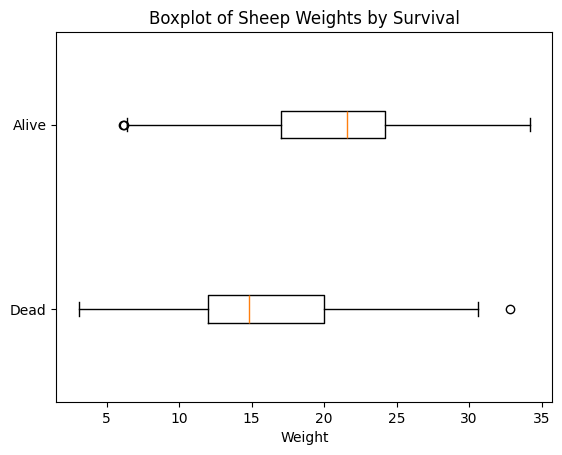

dead sheep mean weight:  15.998113207547169
dead sheep weight std:  5.326672029944064
alive sheep mean weight:  20.645917387127763
alive sheep weight std:  4.899645311819019
num of dead sheep:  318
num of alive sheep:  1041
t-test statistic:  -13.870294216428492
t-test p-value:  3.7011498888008678e-37
95% CI: [ -5.306189087107751 ,  -3.989419272053438 ]


In [47]:
sheep = pd.read_csv('https://stat4ds.rwth-aachen.de/data/Sheep.dat' , sep=r'\s+')
sheep.head()

dead = sheep[sheep['survival'] == 0]['weight']
alive = sheep[sheep['survival'] == 1]['weight']

dead_stat = dead.describe()
alive_stat = alive.describe()

plt.boxplot([dead, alive], tick_labels=['Dead', 'Alive'], vert=False)
plt.xlabel('Weight')
plt.title('Boxplot of Sheep Weights by Survival')
plt.show()

print('dead sheep mean weight: ', dead_stat['mean'])
print('dead sheep weight std: ', dead_stat['std'])
print('alive sheep mean weight: ', alive_stat['mean'])
print('alive sheep weight std: ', alive_stat['std'])

print('num of dead sheep: ', dead.size)
print('num of alive sheep: ', alive.size)

t_result = stats.ttest_ind(dead, alive, equal_var=False)

t_val = t_result.statistic
p_val = t_result.pvalue
print('t-test statistic: ', t_val)
print('t-test p-value: ', p_val)

confidence_interval = t_result.confidence_interval(.95)

print('95% CI: [',confidence_interval.low,', ', confidence_interval.high,']')

H0: Weight of dead sheep = weight of alive sheep, Ha: weight of dead sheep != weight of alive sheep

## Problem 5.23. Sentiment Toward AI and Gender

You will use a mock survey dataset that measures public sentiment toward artificial intelligence. Your task is to generate the dataset, construct a contingency table, and test whether sentiment depends on gender

### Dataset creation

Run the starter code below to generate the dataset as a pandas DataFrame named `df_ai`.

In [11]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(2024)

# Sample size
n = 300

# Categories
sentiments = ["Positive", "Neutral", "Negative"]
genders = ["Male", "Female", "Other"]
usage_levels = ["Daily", "Weekly", "Rarely", "Never"]

# Generate the DataFrame
df_ai = pd.DataFrame(
    {
        "sentiment": np.random.choice(sentiments, size=n, p=[0.44, 0.33, 0.23]),
        "gender": np.random.choice(genders, size=n, p=[0.49, 0.48, 0.03]),
        "age": np.random.randint(18, 75, size=n),
        "ai_usage_frequency": np.random.choice(usage_levels, size=n),
        "trust_in_ai": np.random.randint(1, 6, size=n),
    }
)

df_ai.head()

,sentiment,gender,age,ai_usage_frequency,trust_in_ai
0,Neutral,Male,55,Weekly,2
1,Neutral,Male,23,Rarely,3
2,Positive,Male,27,Daily,5
3,Positive,Female,29,Daily,1
4,Positive,Female,58,Rarely,5


| Variable           | Description                         |
|--------------------|-------------------------------------|
| `sentiment`          | Sentiment toward AI                 |
| `gender`             | Gender identity                     |
| `age`                | Respondent age                      |
| `ai_usage_frequency` | AI tool usage frequency             |
| `trust_in_ai`        | Trust in AI from 1 to 5             |

Using the dataset you just created:

(a) Form a contingency table that cross classifies sentiment by gender.

(b) For the hypothesis $H_0:$ sentiment toward AI is independent of gender, conduct a chi squared test of independence.

(c) Interpret the results in the context of attitudes toward AI.

(a) `Your answer goes here`

(b) `Your answer goes here`


(c) `Your answer goes here`
